In [116]:
import scipy
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
import plotly.graph_objects as go
import altair as alt
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [4]:
database = "crypto_historical_data.db"

In [33]:
def load_crypto_data():
    with sqlite3.connect(database) as conn:
        df = pd.read_sql("SELECT time_close, close FROM btc_price", conn)
    df["time_close"] = pd.to_datetime(df["time_close"])
    return df

df = load_crypto_data()

In [34]:
fitcut = (60, 10*365)

def fit_func(x, p1, p2, p3):
    return p1+p2*np.log(x)+p3*np.log(x)**2

cutdata = df.iloc[fitcut[0]:fitcut[1]]
plotcutdata = df.iloc[fitcut[0]:]
xdata = np.array([x+1 for x in cutdata.index.values])
ydata = np.log(cutdata["close"])

popt, pcov = scipy.optimize.curve_fit(fit_func, xdata, ydata)
polyfit_1d = fit_func(plotcutdata.index.values+1, *popt)

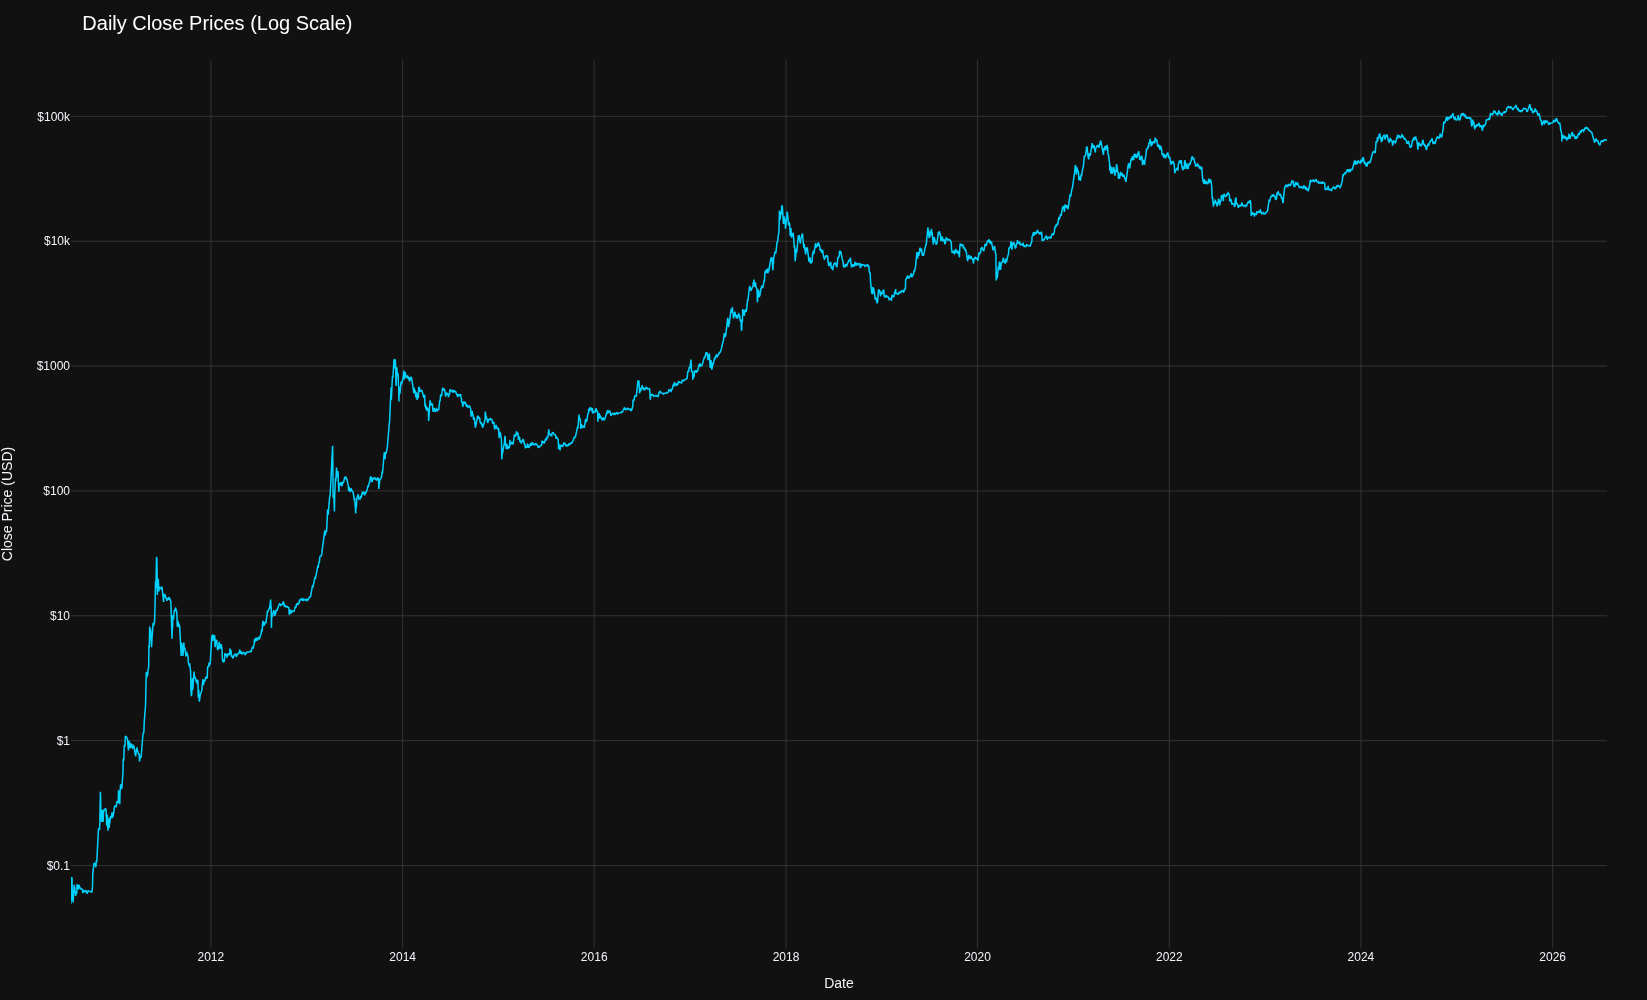

In [35]:
def generate_plot_log_regression(df):
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df["time_close"].tolist(),
            y=df["close"].astype(float).tolist(),
            mode="lines",
            line=dict(color="#00d2ff", width=1.5),
            name="Close Price",
            hovertemplate="<b>Date:</b> %{x|%Y-%m-%d}<br><b>Price:</b> $%{y:,.2f}<extra></extra>",
        )
    )
    
    # --- Layout & Axis Setup ---
    fig.update_layout(
        template="plotly_dark",
        height=1000,
        title=dict(
            text="Daily Close Prices (Log Scale)", font=dict(size=20, color="white")
        ),
        xaxis=dict(
            title="Date",
            type="date",
            showgrid=True,
            gridcolor="#333333",
        ),
        yaxis=dict(
            title="Close Price (USD)",
            type="log",  # Sets the Y-axis scale to logarithmic
            dtick=1,  # Ticks at every power of 10 ($1, $10, $100, $10k, etc.)
            tickprefix="$",
            showgrid=True,
            gridcolor="#333333",
        ),
        hovermode="x unified",
        margin=dict(l=40, r=40, t=60, b=40),
    )
    return fig

generate_plot_log_regression(df)

True

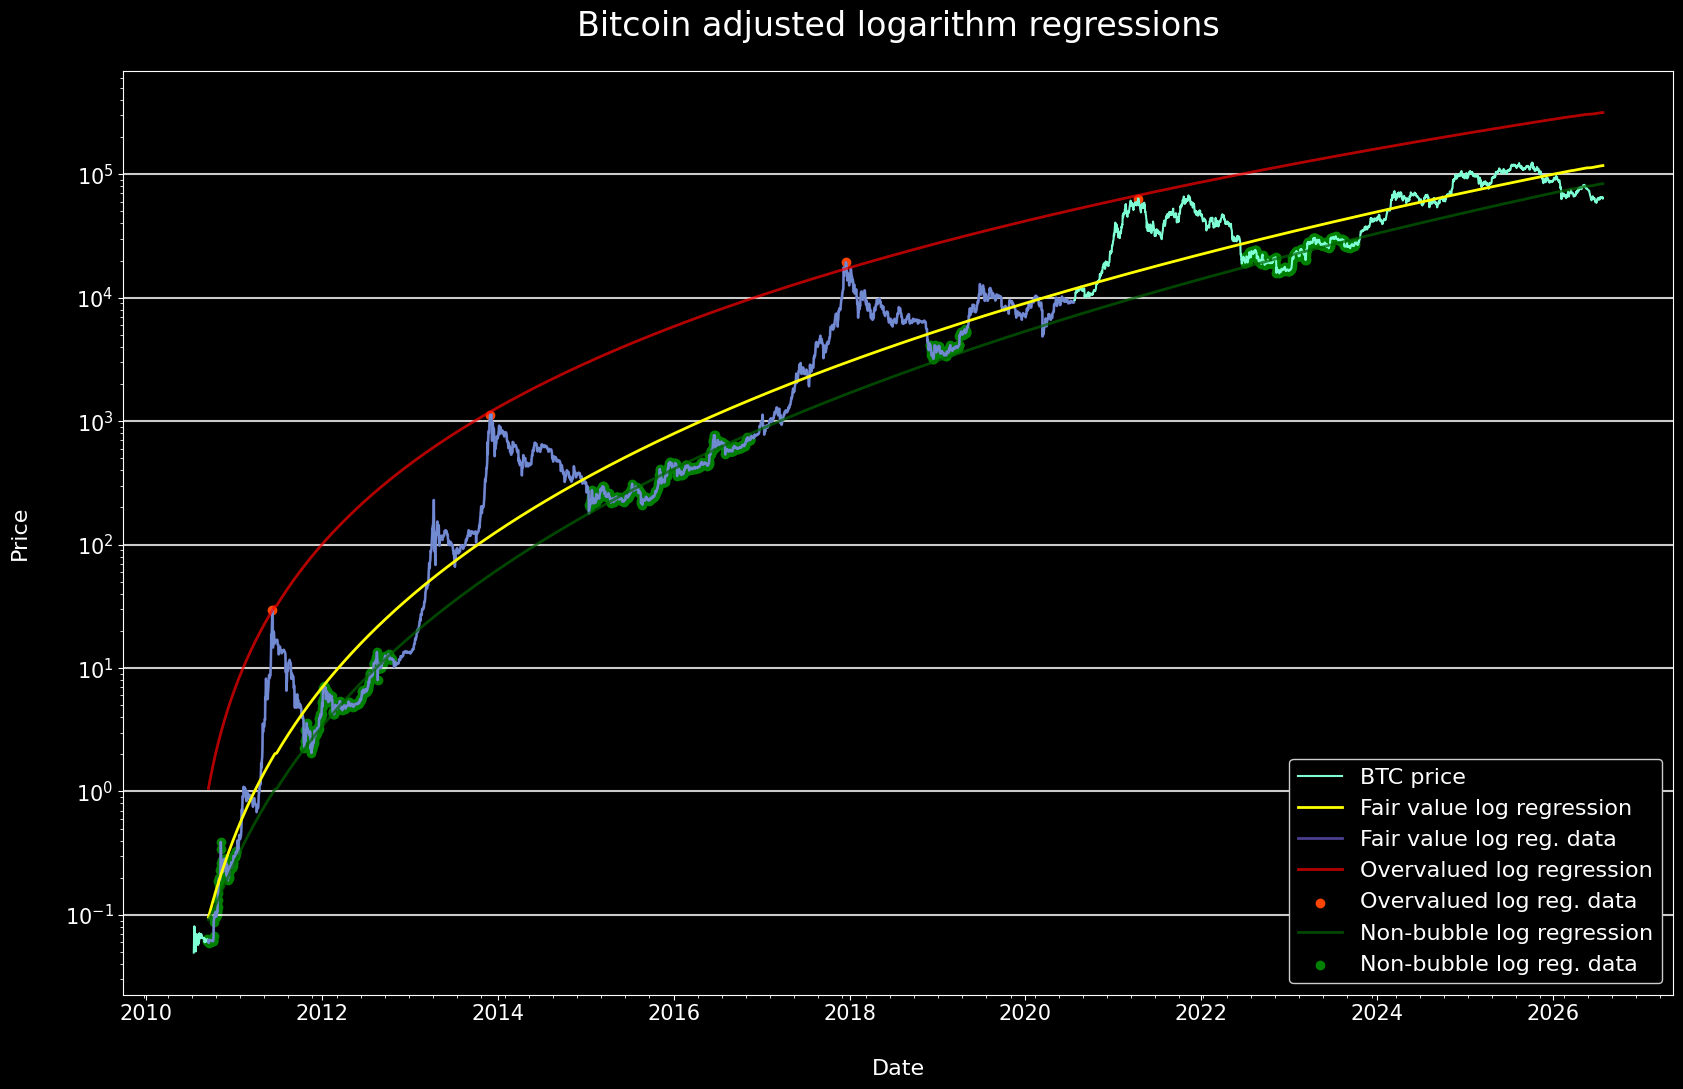

In [54]:
def plot_adj_log_regression_btc(data_raw):
    
    data = data_raw.copy()
    
    # global tops
    
    tops = ("2011-06-08", "2013-11-30", "2017-12-16", "2021-04-14")
    
    # 1. Convert targets to python date objects
    top_dates = [pd.to_datetime(t).date() for t in tops]
    
    # 2. Extract .dt.date from your time_close column to compare
    topcutdata = df[pd.to_datetime(df["time_close"]).dt.date.isin(top_dates)]

    
    xdata = np.array([x+1 for x in topcutdata.index.values])
    ydata = np.log(topcutdata["close"])

    
    popt, pcov = scipy.optimize.curve_fit(fit_func, xdata, ydata)
    top_polyfit_1d = fit_func(plotcutdata.index.values+1, *popt)
    
    # non blubble data
    
    nonbubble = ["2010-09-10", "2011-01-10", "2011-10-19", "2012-10-16", "2015-01-15", "2016-11-14", "2018-12-01", "2019-05-01", "2022-07-01", "2023-10-01"]# "2019-05-08"]
    nonbubblepoints = []
    for i in range(len(nonbubble)//2):
        curdata = data[((data["time_close"] >= nonbubble[i*2]) & (data["time_close"] <= nonbubble[i*2+1]))]
        nonbubblepoints.append(curdata)
    nonbubblecutdata = pd.concat(nonbubblepoints)
    
    xdata = np.array([x+1 for x in nonbubblecutdata.index.values])
    ydata = np.log(nonbubblecutdata["close"])
    
    popt, pcov = scipy.optimize.curve_fit(fit_func, xdata, ydata)
    nb_polyfit_1d = fit_func(plotcutdata.index.values+1, *popt)
    
    # Setting figure up

    plt.style.use('dark_background')

    fig, ax = plt.subplots(figsize=(20, 12))
    plt.yscale("log")

    plt.xlabel("Date", fontsize = 16, labelpad = 25)
    plt.ylabel("Price", fontsize = 16, labelpad = 25)
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize = 15)

    ax.get_xaxis().set_minor_locator(mpl.ticker.MultipleLocator(100))
    #     ax.get_yaxis().set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.grid(axis = "y", which='major', color='w', linewidth=1.5, alpha = 0.8)
    # ax.grid(axis = "y", b=True, which='minor', color='w', linewidth=0.75, linestyle = "dotted", alpha = 0.5)

    #     ax.set_ylim(top = )
    # ax.set_xlim(0, 1500)

    plt.title("Bitcoin adjusted logarithm regressions", fontsize = 24, pad = 25)
    line1,  = ax.plot(data["time_close"], data["close"], color = "aquamarine")
    
    # fair value
    line3,  = ax.plot(cutdata["time_close"], cutdata["close"], color = "slateblue", linewidth = 2, alpha = 0.7)
    line2,  = ax.plot(plotcutdata["time_close"], np.exp(polyfit_1d), color = "yellow", linewidth = 2)
    
    # tops
    line4,  = ax.plot(plotcutdata["time_close"], np.exp(top_polyfit_1d), color = "red", linewidth = 2, alpha = 0.7)
    line5  = ax.scatter(topcutdata["time_close"], topcutdata["close"], color = "orangered")
    
    #non bubble
    line6,  = ax.plot(plotcutdata["time_close"], np.exp(nb_polyfit_1d), color = "darkgreen", linewidth = 2, alpha = 0.7)
    line7  = ax.scatter(nonbubblecutdata["time_close"], nonbubblecutdata["close"], color = "green", alpha = 1)
    
    
    plt.legend(handles = [line1, line2, line3, line4, line5, line6, line7], 
               labels = ["BTC price", "Fair value log regression", "Fair value log reg. data", 
                         "Overvalued log regression", "Overvalued log reg. data", 
                         "Non-bubble log regression", "Non-bubble log reg. data"],
               loc = "lower right", fontsize = 16, framealpha = 1)

    return True

plot_adj_log_regression_btc(df)

In [46]:
tops = ("2011-06-08", "2013-11-30", "2017-12-16", "2021-04-14")

# 1. Convert targets to python date objects
top_dates = [pd.to_datetime(t).date() for t in tops]

# 2. Extract .dt.date from your time_close column to compare
topcutdata = df[pd.to_datetime(df["time_close"]).dt.date.isin(top_dates)]

In [125]:
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scipy.optimize
import streamlit as st


def fit_func(x, p1, p2, p3):
    return p1 + p2 * np.log(x) + p3 * np.log(x) ** 2


def plot_adj_log_regression_btc(data_raw):
    data = data_raw.copy()

    # Data Sanitization
    data["time_close"] = pd.to_datetime(data["time_close"])
    data["close"] = pd.to_numeric(
        data["close"].astype(str).str.replace("$", "").str.replace(",", ""),
        errors="coerce",
    )
    data = (
        data.dropna(subset=["close"])
        .sort_values("time_close")
        .reset_index(drop=True)
    )

    # Calculate x_days (Day 1, 2, 3...)
    start_date = data["time_close"].min()
    data["x_days"] = (data["time_close"] - start_date).dt.days + 1

    # --- 1. Fair Value Calculation ---
    fitcut = (60, min(10 * 365, len(data)))
    cutdata = data.iloc[fitcut[0] : fitcut[1]]
    plotcutdata = data.iloc[fitcut[0] :].copy()

    popt_fv, _ = scipy.optimize.curve_fit(
        fit_func, cutdata["x_days"].values, np.log(cutdata["close"].values)
    )

    # FIX #1: Assign the exponentiated predictions to DataFrame columns
    polyfit_1d = fit_func(plotcutdata["x_days"].values, *popt_fv)
    plotcutdata["Fair Value"] = np.exp(polyfit_1d)

    # --- 2. Global Tops (Overvalued Data) ---
    tops = ("2011-06-08", "2013-11-30", "2017-12-16", "2021-04-14")
    top_dates = [pd.to_datetime(t).date() for t in tops]
    topcutdata = data[data["time_close"].dt.date.isin(top_dates)].copy()

    popt_top, _ = scipy.optimize.curve_fit(
        fit_func, topcutdata["x_days"].values, np.log(topcutdata["close"].values)
    )

    top_polyfit_1d = fit_func(plotcutdata["x_days"].values, *popt_top)
    plotcutdata["Overvalued"] = np.exp(top_polyfit_1d)

    # --- 3. Non-Bubble Data (Support ranges) ---
    nonbubble = [
        "2010-09-10",
        "2011-01-10",
        "2011-10-19",
        "2012-10-16",
        "2015-01-15",
        "2016-11-14",
        "2018-12-01",
        "2019-05-01",
        "2022-07-01",
        "2023-10-01",
    ]

    nonbubblepoints = []
    for i in range(len(nonbubble) // 2):
        s_date = pd.to_datetime(nonbubble[i * 2]).date()
        e_date = pd.to_datetime(nonbubble[i * 2 + 1]).date()
        curdata = data[
            (data["time_close"].dt.date >= s_date)
            & (data["time_close"].dt.date <= e_date)
        ]
        nonbubblepoints.append(curdata)

    nonbubblecutdata = pd.concat(nonbubblepoints)

    popt_nb, _ = scipy.optimize.curve_fit(
        fit_func,
        nonbubblecutdata["x_days"].values,
        np.log(nonbubblecutdata["close"].values),
    )

    nb_polyfit_1d = fit_func(plotcutdata["x_days"].values, *popt_nb)
    plotcutdata["Non-Bubble"] = np.exp(nb_polyfit_1d)

    # --- Altair Layers ---
    base_line = alt.Chart(data[["time_close", "close"]]).mark_line(
        color="#7FFFD4", strokeWidth=1.5
    )
    fv_line = alt.Chart(plotcutdata[["time_close", "Fair Value"]]).mark_line(
        color="#FFFF00", strokeWidth=2
    )
    top_line = alt.Chart(plotcutdata[["time_close", "Overvalued"]]).mark_line(
        color="#FF0000", strokeWidth=2
    )
    top_dots = alt.Chart(topcutdata[["time_close", "close"]]).mark_circle(
        color="#FF4500", size=60
    )

    # FIX #2: Added missing non-bubble line and markers
    nb_line = alt.Chart(plotcutdata[["time_close", "Non-Bubble"]]).mark_line(
        color="#00FF00", strokeWidth=2
    )
    nb_dots = alt.Chart(nonbubblecutdata[["time_close", "close"]]).mark_circle(
        color="#00FF00", size=30
    )

    # --- Combine Chart Layers ---
    chart = (
        alt.layer(
            base_line.encode(
                x=alt.X(
                    "time_close:T",
                    title="Date",
                    axis=alt.Axis(gridColor="#222222", labelColor="#cccccc"),
                ),
                y=alt.Y(
                    "close:Q",
                    scale=alt.Scale(type="log"),
                    title="Price (USD)",
                    axis=alt.Axis(gridColor="#222222", labelColor="#cccccc"),
                ),
                tooltip=[
                    alt.Tooltip("time_close:T", title="Date"),
                    alt.Tooltip("close:Q", format="$,.2f", title="Price"),
                ],
            ),
            fv_line.encode(
                x="time_close:T",
                y="Fair Value:Q",
                tooltip=[
                    alt.Tooltip("time_close:T", title="Date"),
                    alt.Tooltip(
                        "Fair Value:Q", format="$,.2f", title="Fair Value"
                    ),
                ],
            ),
            top_line.encode(
                x="time_close:T",
                y="Overvalued:Q",
                tooltip=[
                    alt.Tooltip("time_close:T", title="Date"),
                    alt.Tooltip(
                        "Overvalued:Q", format="$,.2f", title="Overvalued"
                    ),
                ],
            ),
            top_dots.encode(
                x="time_close:T",
                y="close:Q",
                tooltip=[
                    alt.Tooltip("time_close:T", title="Top Date"),
                    alt.Tooltip("close:Q", format="$,.2f", title="Top Price"),
                ],
            ),
            nb_line.encode(
                x="time_close:T",
                y="Non-Bubble:Q",
                tooltip=[
                    alt.Tooltip("time_close:T", title="Date"),
                    alt.Tooltip(
                        "Non-Bubble:Q", format="$,.2f", title="Non-Bubble"
                    ),
                ],
            ),
            nb_dots.encode(
                x="time_close:T",
                y="close:Q",
                tooltip=[
                    alt.Tooltip("time_close:T", title="Support Date"),
                    alt.Tooltip(
                        "close:Q", format="$,.2f", title="Support Price"
                    ),
                ],
            ),
        )
        .properties(
            width="container",
            height=700,
            title=alt.TitleParams(
                text="Bitcoin Adjusted Logarithmic Regressions", color="white"
            ),
            background="#0e1117",
        )
        .configure_view(strokeWidth=0)
        .interactive()
    )

    return chart

# --- Usage in Streamlit ---
# fig = plot_adj_log_regression_btc_plotly(df)
# st.plotly_chart(fig, use_container_width=True)

In [126]:
plot_adj_log_regression_btc(df)

alt.LayerChart(...)

<Axes: >

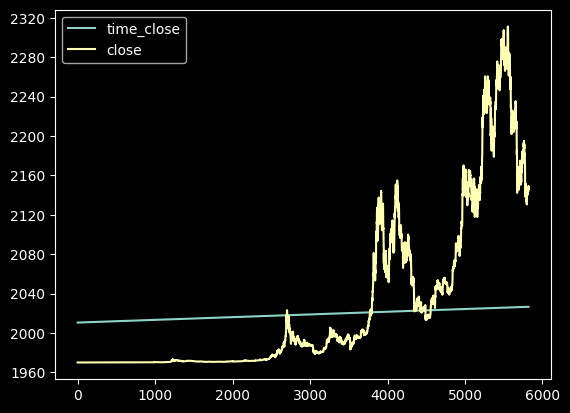

In [112]:
df.plot()